In [17]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt 

import sys
ROOT_DIR = "../"
sys.path.append(ROOT_DIR)

from data_analysis.hsic import run_hsic_analysis

plt.rcParams['figure.dpi'] = 100  # 360 for publication, 100 for notebook visualization
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['lines.linewidth'] = 1.5

In [18]:
dataset_id = "dyconex_SX_MuMi_260302"  # Default dataset

results = run_hsic_analysis(dataset_id=dataset_id)

2026-03-02 14:19:40,151 - INFO - Starting HSIC analysis for dataset: dyconex_SX_MuMi_260302
2026-03-02 14:19:40,160 - INFO - Found cached slopes_summary.csv and param_info.csv, loading from disk...
2026-03-02 14:19:40,188 - INFO - Loaded slopes_wide: (1957, 5)
2026-03-02 14:19:40,189 - INFO - Loaded param_info: (640, 6)
2026-03-02 14:19:40,603 - INFO - Found 500 unique (process, occurrence, step, variable) combinations
2026-03-02 14:19:40,832 - INFO - X_params shape: (1920, 500) (samples x parameters)
2026-03-02 14:19:48,542 - INFO - Found 1920 common samples
2026-03-02 14:19:48,548 - INFO - Found cached hsic_results_delta_A_norm.csv, loading from disk...
2026-03-02 14:19:48,550 - INFO - Found cached hsic_baseline_delta_A_norm.csv, loading from disk...
2026-03-02 14:19:48,552 - INFO - Found cached hsic_results_delta_B_norm.csv, loading from disk...
2026-03-02 14:19:48,555 - INFO - Found cached hsic_baseline_delta_B_norm.csv, loading from disk...
2026-03-02 14:19:48,555 - INFO - 
2026-0

In [19]:
from omegaconf import OmegaConf
from os.path import join

class_map = OmegaConf.load(join("../data/builds", dataset_id, "output", "class_vocabulary.json"))
class_map

{'1': 'Read', '2': 'Set'}

In [20]:
baseline = results["baseline_delta_A_norm"].loc[[results["baseline_delta_A_norm"]["hsic_score"].argmax()]]
baseline_value = baseline["hsic_score"].item()
baseline_signal = baseline["description"]

In [21]:
df = results['hsic_delta_A_norm']
df = df[df["hsic_score"] < 1.0]
df["class"] = df["class"].astype(str).map(class_map)
df.head()

C:\Users\ScipioneFrancesco\AppData\Local\Temp\ipykernel_25980\4204128940.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["class"] = df["class"].astype(str).map(class_map)


,param_name,process,occurrence,step,variable,hsic_score,valid_samples,class,rank
0,Multibond_1_2.0_mul_60,Multibond,1,2.0,mul_60,0.094008,238,Read,1.0
1,Multibond_2_2.0_mul_46,Multibond,2,2.0,mul_46,0.085021,241,Read,2.0
2,Multibond_2_2.0_mul_94,Multibond,2,2.0,mul_94,0.077243,241,Read,3.0
3,Multibond_1_2.0_mul_70,Multibond,1,2.0,mul_70,0.071449,238,Read,4.0
4,Multibond_2_2.0_mul_108,Multibond,2,2.0,mul_108,0.070081,241,Read,5.0


In [22]:
df["process"].unique()

array(['Multibond', 'Microetch'], dtype=object)

In [24]:
df_average = df.groupby(["process", "variable"]).agg({
    "hsic_score":["mean", "std"]
    }).reset_index()

df_average.head()

process variable hsic_score          
                            mean       std
0  Microetch   mic_10   0.011543  0.015493
1  Microetch   mic_11   0.009415  0.011319
2  Microetch   mic_12   0.013261  0.018167
3  Microetch   mic_13   0.006920  0.009360
4  Microetch   mic_14   0.027594  0.018446

Text(0.5, 1.0, 'Microetch')

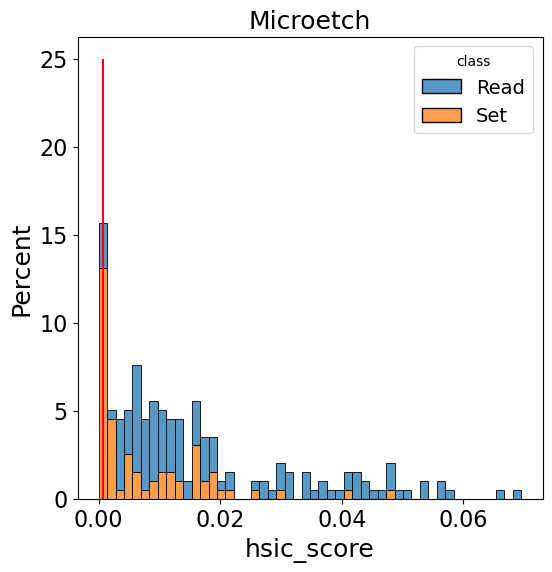

In [27]:
process_label = "Microetch"
fig, ax = plt.subplots()
sns.histplot(data=df[df["process"]==process_label], x="hsic_score", hue="class", multiple="stack", ax=ax, stat="percent", bins=50)
ax.vlines(baseline_value, ymin=0, ymax=25, colors="red")
ax.set_title(process_label)


In [10]:
df_signal = df[df["hsic_score"] > baseline_value]
df_noise = df[df["hsic_score"] < baseline_value]
df_noise.head()

,param_name,process,occurrence,step,variable,hsic_score,valid_samples,class,rank
414,Galvanic_2_1.0_gal_218,Galvanic,2,1.0,gal_218,0.003876,1013,Read,1133.0
818,Galvanic_3_1.0_gal_300,Galvanic,3,1.0,gal_300,0.003874,1147,Read,1134.0
819,Galvanic_3_1.0_gal_301,Galvanic,3,1.0,gal_301,0.003874,1147,Read,1135.0
1871,Plasma_2_1.0_pla_49,Plasma,2,1.0,pla_49,0.003869,1403,Read,1136.0
1877,Plasma_2_1.0_pla_55,Plasma,2,1.0,pla_55,0.003827,1403,Read,1137.0


In [11]:
signal_vars = df_signal["variable"].unique()
noise_vars = df_noise["variable"].unique()
all_vars = set(signal_vars) | set(noise_vars)
signal_noise_vars = set(signal_vars) & set(noise_vars)
signal_only_vars = set(signal_vars) - set(noise_vars)
noise_only_vars = set(noise_vars) - set(signal_vars)

In [12]:
print(len(all_vars))
print(len(signal_noise_vars))
print(len(signal_only_vars))
print(len(noise_only_vars))

351
236
90
25


In [13]:
noise_only_vars

{'mul_11',
 'mul_111',
 'mul_112',
 'mul_113',
 'mul_12',
 'mul_13',
 'mul_14',
 'mul_19',
 'mul_20',
 'mul_21',
 'mul_22',
 'mul_33',
 'mul_41',
 'mul_65',
 'mul_71',
 'mul_72',
 'mul_73',
 'mul_89',
 'mul_97',
 'pla_42',
 'pla_43',
 'pla_44',
 'pla_45',
 'pla_46',
 'pla_47'}

In [14]:
df_X = pd.read_parquet("../data/builds/dyconex_251117/output/df_input.parquet")
df_X.head()

,design_version,group,position,process,variable,value,date,parameter,value_norm,order,year,month,day,hour,minute,design_version_position,layer,occurrence,step
0,426816_B,CUEX_13,40.0,Laser,las_11,NaN,NaT,Pulsenergie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,426816_B_40,"3,4",1,1.0
1,426816_B,CUEX_13,40.0,Laser,las_12,NaN,NaT,SkalierungX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,426816_B_40,"3,4",1,1.0
2,426816_B,CUEX_13,40.0,Laser,las_13,NaN,NaT,SkalierungY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,426816_B_40,"3,4",1,1.0
4,426816_B,CUEX_13,40.0,Laser,las_15,NaN,NaT,T_Drv0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,426816_B_40,"3,4",1,1.0
5,426816_B,CUEX_13,40.0,Laser,las_16,NaN,NaT,T_Drv1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,426816_B_40,"3,4",1,1.0


In [15]:
df_X[df_X["variable"]=="mul_111"]

,design_version,group,position,process,variable,value,date,parameter,value_norm,order,year,month,day,hour,minute,design_version_position,layer,occurrence,step
350,426816_B,CUEX_13,180.0,Multibond,mul_111,0.003996,2022-08-12 11:22:00,G_M8_SinkConductivityHyst_SP Mean,1.0,3.0,2022.0,8.0,12.0,11.0,22.0,426816_B_180,"3,4",1,1.0
621,426816_B,CUEX_13,390.0,Multibond,mul_111,0.003996,2022-09-07 16:06:00,G_M8_SinkConductivityHyst_SP Mean,1.0,8.0,2022.0,9.0,7.0,16.0,6.0,426816_B_390,"2,5",2,1.0
1508,426816_B,CUEX_17,180.0,Multibond,mul_111,0.003996,2022-08-12 11:22:00,G_M8_SinkConductivityHyst_SP Mean,1.0,3.0,2022.0,8.0,12.0,11.0,22.0,426816_B_180,"3,4",1,1.0
1779,426816_B,CUEX_17,390.0,Multibond,mul_111,0.003996,2022-09-07 16:06:00,G_M8_SinkConductivityHyst_SP Mean,1.0,8.0,2022.0,9.0,7.0,16.0,6.0,426816_B_390,"2,5",2,1.0
2666,426816_B,CUEX_20,180.0,Multibond,mul_111,0.003996,2022-08-12 11:22:00,G_M8_SinkConductivityHyst_SP Mean,1.0,3.0,2022.0,8.0,12.0,11.0,22.0,426816_B_180,"3,4",1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2147657,453828_B,CXOL_3,410.0,Multibond,mul_111,0.003996,2023-11-13 11:20:00,G_M8_SinkConductivityHyst_SP Mean,1.0,8.0,2023.0,11.0,13.0,11.0,20.0,453828_B_410,"2,5",2,2.0
2148951,453828_B,CXOL_30,410.0,Multibond,mul_111,0.003996,2023-11-13 11:20:00,G_M8_SinkConductivityHyst_SP Mean,1.0,8.0,2023.0,11.0,13.0,11.0,20.0,453828_B_410,"2,5",2,2.0
2150245,453828_B,CXOL_33,410.0,Multibond,mul_111,0.003996,2023-11-13 11:20:00,G_M8_SinkConductivityHyst_SP Mean,1.0,8.0,2023.0,11.0,13.0,11.0,20.0,453828_B_410,"2,5",2,2.0
2151294,453828_B,CXOL_5,410.0,Multibond,mul_111,0.003996,2023-11-13 11:20:00,G_M8_SinkConductivityHyst_SP Mean,1.0,7.0,2023.0,11.0,13.0,11.0,20.0,453828_B_410,"2,5",2,2.0
